In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append("../../training_data/")

In [3]:
from utils.utils import *

In [4]:
extra_path = "../../training_data/7.Extra_set"
extra_original_cifs_path = f"{extra_path}/origcifs"

extra_structures_path = "cifs"
os.makedirs(extra_structures_path, exist_ok=True)

extra_pockets_path = "pockets"
os.makedirs(extra_pockets_path, exist_ok=True)

extra_features_path = "."
os.makedirs("features", exist_ok=True)

Cif.path = extra_structures_path
Cif.original_cifs_path = extra_original_cifs_path

# Data

In [5]:
news_sitesf = f"{extra_path}/news_sites.pkl"

with open(news_sitesf, "rb") as f:
    news_sites = {
        k: v
        for k, v in pd.read_pickle(f).items()
        if k not in ('6l57', '6t65', '6zod', '7p2l', '8tb7',) # they were annotated in the new dict because they are in the same primary reference as hits but were already in the database
    }

news_sites

{'22mj': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   2394         A1MDP             H               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   2394                 ?         407        A1MDP            A   
   
        pdbx_PDB_model_num pdbx_label_index  
   2394                  1              407  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            THR             A               1          118                 ?   
   1            PRO             A               1          119                 ?   
   2            THR             A               1          120                 ?   
   3            LYS             A               1          129                 ?   
   4            GLY             A               1          130                 ?   
   5            GLY             A               1          131                 ?   
   6            VA

In [6]:
news_seqsf = f"{extra_path}/news_seqs.pkl"

with open(news_seqsf, "rb") as f:
    news_seqs = pd.read_pickle(f)

news_seqs

{('21du',
  '5',
  'E'): 'THFGVLMDLPRSASQLDARNTKVLTFISYIGCGISAIFSAATLLTYVAFEKLRRDYPSKILMNLSTALLFLNLLFLLDGWITSFNVDGLCIAVAVLLHFFLLATFTWMGLEAIHMYIALVKVFNTYIRRYILKFCIIGWGLPALVVSVVLASRNNNEVYGKESYGKEKGDEFCWIQDPVIFYVTCAGYFGVMFFLNIAMFIVVMVQICGRNGKRSNRTLREEVLRNLRSVVSLTFLLGMTWGFAFFAWGPLNIPFMYLFSIFNSLQGLFIFIFHCAMKENVQKQWRQ',
 ('22mj',
  '1',
  'A'): 'KGRRLSIHVVTWNVASAAPPLDLSDLLQLNNRNLNLDIYVIGLQELNSGIISLLSDAAFNDSWSSFLMDVLSPLSFIKVSHVRMQGILLLVFAKYQHLPYIQILSTKSTPTGLFGYWGNKGGVNICLKLYGYYVSIINCHLPPHISNNYQRLEHFDRILEMQNCEGRDIPNILDHDLIIWFGDMNFRIEDFGLHFVRESIKNRCYGGLWEKDQLSIAKKHDPLLREFQEGRLLFPPTYKFDRNSNDYDTSEKKRKPAWTDRILWRLKRQPAKANPSGFLLTQKDYSSHMTYGISDHKPVSGTFDLELKPL',
 ('6l57',
  '1',
  'A'): 'VQTVTLIPGDGIGPEISAAVMKIFDAAKAPIQWEERNVTAIQGPGGKWMIPSEAKESMDKNKMGLKGPLKTPIAAGHPSMNLLLRKTFDLYANVRPCVSIEGYKTPYTDVNIVTIRENTEGEYSGIEHVIVDGVVQSIKLITEGASKRIAEFAFEYARNNHRSNVTAVHKANIMRMSDGLFLQKCREVAESCKDIKFNEMYLDTVCLNMVQDPSQFDVLVMPNLYGDILSDLCAGLIGGLGVTPSGNIGANGVAIFESVHGTAPDIAGKDMANPTALLLSAVMMLRHMGLFDHAARIEAACFATIKDGKSLTKDLGGNA

# -mers annotations

In [7]:
mmseqs = pd.read_csv(f"{extra_path}/mmseqs2/second_cluster.tsv", sep="\t", header=None)
mmseqs

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,7v6g_1_A,7v6g_1_A
3,7v6g_1_A,7v6g_1_B
4,6r8g_1_B,6r8g_1_B
...,...,...
3700,8fe1_2_E,8fe1_1_B
3701,8fe1_2_E,8fe1_1_C
3702,4op0_1_A,4op0_1_A
3703,2be9_2_B,2be9_2_B


In [8]:
# Map each cluster rep to a unique cluster ID
mmseq_ids = {cid: i for i, cid in enumerate(mmseqs[0].unique())}
mmseq_ids

{'21du_5_E': 0,
 '22mj_1_A': 1,
 '7v6g_1_A': 2,
 '6r8g_1_B': 3,
 '6s3a_1_A': 4,
 '6vvq_1_C': 5,
 '6on4_1_A': 6,
 '6ymh_1_B': 7,
 '6z1m_1_A': 8,
 '6z74_1_A': 9,
 '7ac8_1_A': 10,
 '7agj_1_A': 11,
 '7e1n_1_A': 12,
 '7e40_2_B': 13,
 '7egk_2_B': 14,
 '7f8p_1_A': 15,
 '7gqu_1_A': 16,
 '7k1c_1_B': 17,
 '7oy0_1_A': 18,
 '7p2v_1_A': 19,
 '7pol_1_A': 20,
 '7pt0_1_A': 21,
 '7qpn_1_A': 22,
 '7ry1_1_A': 23,
 '7snh_1_A': 24,
 '7sql_1_C': 25,
 '7u3a_1_A': 26,
 '7u4k_1_A': 27,
 '7v39_1_B': 28,
 '6iy8_1_A': 29,
 '7yg5_1_A': 30,
 '7zpe_1_A': 31,
 '8aq6_1_H': 32,
 '8cgw_1_A': 33,
 '8crc_1_A': 34,
 '8d4i_1_A': 35,
 '8dsc_1_A': 36,
 '8e1u_1_A': 37,
 '8e23_1_A': 38,
 '8fdb_2_B': 39,
 '8f4s_1_A': 40,
 '8fpi_1_A': 41,
 '8hub_1_B': 42,
 '8hx9_1_A': 43,
 '8jb3_1_A': 44,
 '8jp0_1_A': 45,
 '8ooo_1_A': 46,
 '8p23_1_B': 47,
 '8qa6_1_A': 48,
 '8qtk_1_A': 49,
 '8qud_1_A': 50,
 '9hg1_1_A': 51,
 '8sev_1_A': 52,
 '8thm_1_B': 53,
 '8uk6_1_A': 54,
 '8v81_1_A': 55,
 '8xlr_1_A': 56,
 '8y6w_5_E': 57,
 '9d2r_1_A': 58,
 '9dnm_

In [9]:
# Define each PDB (not each sequence) by the cluster IDs to which the sequences of its chains belong to (# of chains per pdb per cluster) (only clust. reps of news)
mmer_clust_ids = {}

for i, row in tqdm(
    (
        mmseqs
        .loc[lambda x: [i.split("_")[0] in news_sites for i in x[1]]]
        .iterrows()
    ), 
    smoothing=0
):
    p, entity_id, asym_id = row[1].split("_")
    cid = mmseq_ids[row[0]]
    if p not in mmer_clust_ids:
        mmer_clust_ids[p] = {}
    mmer_clust_ids[p][cid] = mmer_clust_ids[p].get(cid, 0) + 1

dict(sorted(mmer_clust_ids.items(), key=lambda x: x[0]))

0it [00:00, ?it/s]

{'21du': {0: 1},
 '22mj': {1: 1},
 '6iy8': {29: 4},
 '6on4': {6: 1},
 '6r8g': {3: 4},
 '6s3a': {4: 1},
 '6t3w': {4: 1},
 '6vvq': {5: 1},
 '6ymh': {7: 1},
 '6z1m': {8: 1},
 '6z74': {9: 1},
 '7ac8': {10: 1},
 '7agj': {11: 2},
 '7e1n': {12: 2},
 '7e40': {13: 1},
 '7egk': {14: 3},
 '7f8p': {15: 1},
 '7gqu': {16: 1},
 '7k1c': {17: 2},
 '7oy0': {18: 1},
 '7p2v': {19: 1},
 '7pol': {20: 2},
 '7pt0': {21: 1},
 '7qpn': {22: 1},
 '7ry1': {23: 1},
 '7snh': {24: 4},
 '7sql': {25: 4},
 '7u3a': {26: 2},
 '7u4k': {27: 1},
 '7v39': {28: 1},
 '7v6g': {2: 2},
 '7vqf': {29: 1},
 '7yg5': {30: 1},
 '7zpe': {31: 1},
 '8aq6': {32: 2},
 '8cgw': {33: 1},
 '8crc': {34: 1},
 '8d4i': {35: 2},
 '8dsc': {36: 2},
 '8e1u': {37: 2},
 '8e23': {38: 1},
 '8f4s': {40: 1},
 '8fdb': {39: 2},
 '8fpi': {41: 1},
 '8hub': {42: 3},
 '8hx9': {43: 1},
 '8jb3': {44: 1},
 '8jp0': {45: 1},
 '8k9l': {83: 1},
 '8ooo': {46: 12},
 '8p23': {47: 2},
 '8qa6': {48: 2},
 '8qni': {49: 1},
 '8qtk': {49: 1},
 '8qud': {50: 4},
 '8sev': {52: 4},
 '

New PDBs that are heteromers (only two heterodimers) have chains that are the only cluster member for their respective cluster.

<br>

In [10]:
# Only representatives
mmer_clust_ids_reps = {
    k: v
    for k,v in mmer_clust_ids.items()
    if k in mmseqs[0].apply(lambda x: x.split("_", 1)[0]).unique()
}

len(mmer_clust_ids_reps), mmer_clust_ids_reps

(85,
 {'21du': {0: 1},
  '22mj': {1: 1},
  '7v6g': {2: 2},
  '6r8g': {3: 4},
  '6s3a': {4: 1},
  '6vvq': {5: 1},
  '6on4': {6: 1},
  '6ymh': {7: 1},
  '6z1m': {8: 1},
  '6z74': {9: 1},
  '7ac8': {10: 1},
  '7agj': {11: 2},
  '7e1n': {12: 2},
  '7e40': {13: 1},
  '7egk': {14: 3},
  '7f8p': {15: 1},
  '7gqu': {16: 1},
  '7k1c': {17: 2},
  '7oy0': {18: 1},
  '7p2v': {19: 1},
  '7pol': {20: 2},
  '7pt0': {21: 1},
  '7qpn': {22: 1},
  '7ry1': {23: 1},
  '7snh': {24: 4},
  '7sql': {25: 4},
  '7u3a': {26: 2},
  '7u4k': {27: 1},
  '7v39': {28: 1},
  '6iy8': {29: 4},
  '7yg5': {30: 1},
  '7zpe': {31: 1},
  '8aq6': {32: 2},
  '8cgw': {33: 1},
  '8crc': {34: 1},
  '8d4i': {35: 2},
  '8dsc': {36: 2},
  '8e1u': {37: 2},
  '8e23': {38: 1},
  '8fdb': {39: 2},
  '8f4s': {40: 1},
  '8fpi': {41: 1},
  '8hub': {42: 3},
  '8hx9': {43: 1},
  '8jb3': {44: 1},
  '8jp0': {45: 1},
  '8ooo': {46: 12},
  '8p23': {47: 2},
  '8qa6': {48: 2},
  '8qtk': {49: 1},
  '8qud': {50: 4},
  '9hg1': {51: 8},
  '8sev': {52: 4

In [11]:
dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 2
    ), 
    key=lambda x: x[0]
))

{'9ohl': {75: 1, 76: 1}, '9xro': {81: 1, 82: 1}}

In [12]:
# decision: heteromers will only contain chains in contact with modulators.
# for homomers, all chains in assembly/manual annotation will be included

# 9ohl is fine
# 9xro is a trimer, but the dimer is fine

good_oligomers = {
    "9ohl": None, # None means the already-selected chains in the .cif will be used (no .cif reprocessing)
    "9xro": None
}

In [13]:
homomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 1 and tuple(v.values())[0] > 1
    ), 
    key=lambda x: tuple(x[1].values())[0],
    reverse=True
))

len(homomers), homomers

(35,
 {'8ooo': {46: 12},
  '9hg1': {51: 8},
  '9z2f': {85: 8},
  '8thm': {53: 6},
  '9ema': {63: 6},
  '6r8g': {3: 4},
  '7snh': {24: 4},
  '7sql': {25: 4},
  '6iy8': {29: 4},
  '8qud': {50: 4},
  '8sev': {52: 4},
  '9it0': {66: 4},
  '9p3o': {79: 4},
  '9zq0': {86: 4},
  '7egk': {14: 3},
  '8hub': {42: 3},
  '7v6g': {2: 2},
  '7agj': {11: 2},
  '7e1n': {12: 2},
  '7k1c': {17: 2},
  '7pol': {20: 2},
  '7u3a': {26: 2},
  '8aq6': {32: 2},
  '8d4i': {35: 2},
  '8dsc': {36: 2},
  '8e1u': {37: 2},
  '8fdb': {39: 2},
  '8p23': {47: 2},
  '8qa6': {48: 2},
  '8xlr': {56: 2},
  '9du7': {61: 2},
  '9hgm': {65: 2},
  '9l65': {67: 2},
  '9m8v': {71: 2},
  '9yic': {84: 2}})

In [14]:
# decision: only tetramers and down

# 7sql has bad ligand quality
#### 9zq0 is from a preprint
#### 7egk is an hexamer (heterodimer of homotimers)
#### 8hub is a tetramer #and has bad ligand quality
# 8aq6 bad ligand quality
# 8e1u has ok-bad ligand quality
# 8v90 has bad ligand quality
# 9yic has bad ligand quality

good_oligomers.update({
    k: None
    for k, v in homomers.items()
    if (
        k not in ["7egk", '8hub', "9zq0"]#['7sql', '9zq0', '8hub', '8aq6', '8e1u', '8v90', '9yic']
        and tuple(v.values())[0] <= 4 # tetramers or less
    )
})

good_oligomers['8hub'] = ["A", "B", "C", "D"]

good_oligomers

{'9ohl': None,
 '9xro': None,
 '6r8g': None,
 '7snh': None,
 '7sql': None,
 '6iy8': None,
 '8qud': None,
 '8sev': None,
 '9it0': None,
 '9p3o': None,
 '7v6g': None,
 '7agj': None,
 '7e1n': None,
 '7k1c': None,
 '7pol': None,
 '7u3a': None,
 '8aq6': None,
 '8d4i': None,
 '8dsc': None,
 '8e1u': None,
 '8fdb': None,
 '8p23': None,
 '8qa6': None,
 '8xlr': None,
 '9du7': None,
 '9hgm': None,
 '9l65': None,
 '9m8v': None,
 '9yic': None,
 '8hub': ['A', 'B', 'C', 'D']}

In [15]:
monomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 1 and tuple(v.values())[0] == 1
    ), 
    key=lambda x: x[0]
))

print(len(monomers), monomers)

48 {'21du': {0: 1}, '22mj': {1: 1}, '6on4': {6: 1}, '6s3a': {4: 1}, '6vvq': {5: 1}, '6ymh': {7: 1}, '6z1m': {8: 1}, '6z74': {9: 1}, '7ac8': {10: 1}, '7e40': {13: 1}, '7f8p': {15: 1}, '7gqu': {16: 1}, '7oy0': {18: 1}, '7p2v': {19: 1}, '7pt0': {21: 1}, '7qpn': {22: 1}, '7ry1': {23: 1}, '7u4k': {27: 1}, '7v39': {28: 1}, '7yg5': {30: 1}, '7zpe': {31: 1}, '8cgw': {33: 1}, '8crc': {34: 1}, '8e23': {38: 1}, '8f4s': {40: 1}, '8fpi': {41: 1}, '8hx9': {43: 1}, '8jb3': {44: 1}, '8jp0': {45: 1}, '8qtk': {49: 1}, '8uk6': {54: 1}, '8v81': {55: 1}, '8y6w': {57: 1}, '9d2r': {58: 1}, '9dnm': {59: 1}, '9dol': {60: 1}, '9ebs': {62: 1}, '9fsj': {64: 1}, '9l80': {68: 1}, '9l84': {69: 1}, '9lhf': {70: 1}, '9mfs': {72: 1}, '9o2m': {73: 1}, '9oga': {74: 1}, '9oul': {78: 1}, '9prs': {77: 1}, '9rhg': {80: 1}, '9ydr': {83: 1}}


In [16]:
diverse_newsf = f"{extra_path}/diverse_news.pkl"

with open(diverse_newsf, "rb") as f:
    diverse_news = pickle.load(f)

print(len(diverse_news), diverse_news)

30 {'21du': {'label_asym_id': ['F']}, '22mj': {'label_asym_id': ['H']}, '6s3a': {'label_asym_id': ['B']}, '6vvq': {'label_asym_id': ['E']}, '6z1m': {'label_asym_id': ['D']}, '7e40': {'label_asym_id': ['F']}, '7f8p': {'label_asym_id': ['G']}, '7gqu': {'label_asym_id': ['D']}, '7p2v': {'label_asym_id': ['F']}, '7qpn': {'label_asym_id': ['C']}, '7u4k': [{'label_asym_id': ['B']}], '7v39': [{'label_asym_id': ['F']}], '7yg5': {'label_asym_id': ['V']}, '7zpe': {'label_asym_id': ['G']}, '8cgw': {'label_asym_id': ['P']}, '8crc': {'label_asym_id': ['C']}, '8f4s': {'label_asym_id': ['D']}, '8fpi': {'label_asym_id': ['F']}, '8jp0': {'label_asym_id': ['B']}, '8qtk': {'label_asym_id': ['E']}, '8uk6': {'label_asym_id': ['C']}, '8v81': {'label_asym_id': ['L']}, '8y6w': {'label_asym_id': ['G']}, '9dol': {'label_asym_id': ['F']}, '9ebs': {'label_asym_id': ['F']}, '9fsj': {'label_asym_id': ['B']}, '9mfs': {'label_asym_id': ['B']}, '9o2m': {'label_asym_id': ['C']}, '9prs': {'label_asym_id': ['C']}, '9oul'

In [17]:
monomers_left = {
    k: v 
    for k, v in monomers.items() 
    if k not in (
        list(diverse_news) 
        + [
            # '7e40', '7u4k', '7v39', '8cgw', # bad ligand resolution from original nb
            '9dnm', '9l80', '9l84', '9oga', '9ydr' # preprints from original nb
        ] 
    )
}

len(monomers_left), monomers_left

(13,
 {'6on4': {6: 1},
  '6ymh': {7: 1},
  '6z74': {9: 1},
  '7ac8': {10: 1},
  '7oy0': {18: 1},
  '7pt0': {21: 1},
  '7ry1': {23: 1},
  '8e23': {38: 1},
  '8hx9': {43: 1},
  '8jb3': {44: 1},
  '9d2r': {58: 1},
  '9lhf': {70: 1},
  '9rhg': {80: 1}})

From original notebook: **Differences between the annotated and the extracted oligomeric state:**
- 6on4 is a functional dimer
- 6ymh is a functional dimer
- 6z74 is a functional tetramer but the allosteric site is only on 1 chain
- 7ac8 dimer
- 7oy0 is a functional dimer
- 7pt0 is a functional dimer but the allosteric site is only on 1 chain
- 7ry1 is a hexamer and the model is a trimer which could reconstruct the hexamer in the assembly, but they haven't done it
- 8e23 is probably a tetramer but neither the model or the assembly are
- 8hx9 dimer
- 8jb3 is a functional tetramer
- 9d2r is a functional dimer, but model is monomeric and thus assembly is repetition-based
- 9lhf is a dimer but there is only 1 molecule interacting with 1 chain
- 9rhg is a functional dimer but the allosteric site is only on 1 chain

<br>

In [18]:
good_oligomers.update({
    '6on4': ["A", "B"],
    '6ymh': ["A", "B"],
    '6z74': ["A", "B", "C", "D"],
    '7ac8': ["A", "B"],
    # '7oy0': {15: 1}, # repetition-based assembly, dimer not available model
    '7pt0': ["A", "B"],
    # '7ry1': # is a hexamer
    # '8e23': {37: 1}, # tetramer, not available in model
    '8hx9': ["A", "B"], # bad ligand quality
    # '8jb3': {43: 1}, # it is a functional tetramer but isn't in model nor assembly
    # '9b96': {57: 1}, # repetition-based assembly, dimer not available model
    # '9d2r': {58: 1}, # repetition-based assembly, dimer not available model
    '9lhf': ["A", "B"],
    '9rhg': ["A", "B"]
})

In [19]:
if (
    "8aq6" in monomers_left
    or len(Cif("8aq6", f"{extra_path}/cifs/8aq6.cif").residues.label_asym_id.unique()) == 1
):
    print("8aq6")
    good_oligomers["8aq6"] = ["G", "H"]

8aq6


In [20]:
len(good_oligomers), good_oligomers

(38,
 {'9ohl': None,
  '9xro': None,
  '6r8g': None,
  '7snh': None,
  '7sql': None,
  '6iy8': None,
  '8qud': None,
  '8sev': None,
  '9it0': None,
  '9p3o': None,
  '7v6g': None,
  '7agj': None,
  '7e1n': None,
  '7k1c': None,
  '7pol': None,
  '7u3a': None,
  '8aq6': ['G', 'H'],
  '8d4i': None,
  '8dsc': None,
  '8e1u': None,
  '8fdb': None,
  '8p23': None,
  '8qa6': None,
  '8xlr': None,
  '9du7': None,
  '9hgm': None,
  '9l65': None,
  '9m8v': None,
  '9yic': None,
  '8hub': ['A', 'B', 'C', 'D'],
  '6on4': ['A', 'B'],
  '6ymh': ['A', 'B'],
  '6z74': ['A', 'B', 'C', 'D'],
  '7ac8': ['A', 'B'],
  '7pt0': ['A', 'B'],
  '8hx9': ['A', 'B'],
  '9lhf': ['A', 'B'],
  '9rhg': ['A', 'B']})

## .cif reprocessing

In [21]:
from utils.new_pdbs import Pdb
from utils.structure_fixing import get_fixed_structure

In [22]:
errors = []

for new, chains in tqdm(tuple(good_oligomers.items()), smoothing=0):
    new = new.lower()
    newf = f"{extra_structures_path}/{new}.cif"
    
    if chains is None:
        if not os.path.isfile(newf):
            os.system(f"cp {extra_path}/cifs/{new}.cif {newf}")
        continue
    
    else:
        if (
            os.path.isfile(newf) 
            and set(Cif(new, newf).residues.label_asym_id.unique()) == set(chains)
        ):
            continue

        pdb = Pdb(new)
        origciff = f"{extra_original_cifs_path}/{new}_updated.cif.gz"
        pdb.filename = origciff
        pdb.cif.filename = origciff
        p = pdb
        
        try:
            get_fixed_structure(pdb, pdb, chains, extra_structures_path, save=True)
        except Exception as e:
            print(pdb, e)
            errors[pdb] = e

  0%|          | 0/38 [00:00<?, ?it/s]

# Pockets

In [23]:
from utils.pocket_utils import Pocket, get_pocket_view, get_pockets_info, get_mean_pocket_features

In [24]:
view_pocket = lambda pdb, pocket: get_pocket_view(
    pdb = pdb, 
    cif = Cif(pdb),
    pocket = pocket,
    pockets_path = extra_pockets_path,
    sites = news_sites[pdb]
)

## "Old" FPocket

In [25]:
def hunt_pockets(pdb):    
    path = f"{extra_pockets_path}/{pdb}"
    if os.path.isdir(path):
        return
    else:
        print(pdb)
        os.makedirs(path, exist_ok=True)
        os.system(f"cp {extra_structures_path}/{pdb}.cif {path}/")
        os.system(f"fpocket -m 3 -M 6 -i 35 --file {path}/{pdb}.cif") # utils/external/fpocket/bin/fpocket

In [26]:
for pdb in tqdm(good_oligomers, smoothing=0):
    hunt_pockets(pdb)

  0%|          | 0/38 [00:00<?, ?it/s]

### Process

In [27]:
pockets = pd.DataFrame((
    pocket
    for pdb in tqdm(good_oligomers, smoothing=0)
    for pocket in get_pockets_info(
        Cif(pdb), 
        sites = news_sites[pdb],
        pockets_path = extra_pockets_path
    )
))

pockets

  0%|          | 0/38 [00:00<?, ?it/s]

,pdb,pocket,nres,site_in_pocket,pocket_in_site
0,9ohl,pocket16,8,0.000000,0.000000
1,9ohl,pocket11,19,0.000000,0.000000
2,9ohl,pocket15,26,0.863636,0.730769
3,9ohl,pocket7,12,0.000000,0.000000
4,9ohl,pocket13,7,0.000000,0.000000
...,...,...,...,...,...
1895,9rhg,pocket19,8,0.000000,0.000000
1896,9rhg,pocket21,11,0.000000,0.000000
1897,9rhg,pocket33,13,0.000000,0.000000
1898,9rhg,pocket36,24,0.000000,0.000000


In [28]:
len(good_oligomers), len(pockets.pdb.unique())

(38, 38)

### Pocket size

In [29]:
pockets.sort_values("nres", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site
1392,8qa6,pocket1,384,0.593220,0.091146
1790,7pt0,pocket1,131,0.909091,0.152672
1322,8p23,pocket1,131,0.000000,0.000000
1746,6z74,pocket1,119,0.360000,0.075630
229,6iy8,pocket1,110,0.000000,0.000000
...,...,...,...,...,...
308,8qud,pocket60,5,0.000000,0.000000
844,9p3o,pocket151,5,0.000000,0.000000
749,9p3o,pocket153,5,0.000000,0.000000
871,9p3o,pocket115,5,0.000000,0.000000


<Axes: >

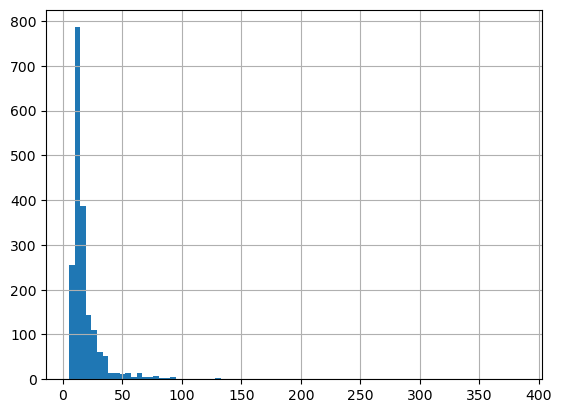

In [30]:
pockets.nres.hist(bins=80)

### Labelling

In [31]:
pockets["label"] = 0
pockets.loc[
    pockets.loc[
        lambda x: round(x["site_in_pocket"], 2) >= 0.65
    ].index, 
    "label"
] = 1
# pockets["label"] = pockets["label"].fillna(0).astype(int)

pockets.sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
295,8qud,pocket16,63,0.950000,0.301587,1
306,8qud,pocket64,66,0.950000,0.287879,1
322,8qud,pocket1,64,0.950000,0.296875,1
328,8qud,pocket2,65,0.950000,0.292308,1
919,7v6g,pocket6,24,0.944444,0.708333,1
1230,8e1u,pocket10,78,0.933333,0.179487,1
1264,8e1u,pocket6,36,0.933333,0.388889,1
28,9xro,pocket1,81,0.931034,0.333333,1
1325,8p23,pocket58,58,0.925926,0.431034,1
1790,7pt0,pocket1,131,0.909091,0.152672,1


In [32]:
print("pdb", "sites", "pkts")
for pdb in good_oligomers:
    print(pdb, len(news_sites[pdb]), pockets.query(f"pdb == '{pdb}'").label.sum())

pdb sites pkts
9ohl 1 1
9xro 1 1
6r8g 4 4
7snh 4 0
7sql 1 0
6iy8 4 4
8qud 4 4
8sev 4 0
9it0 4 0
9p3o 4 4
7v6g 2 2
7agj 2 0
7e1n 2 2
7k1c 2 1
7pol 2 2
7u3a 2 0
8aq6 1 1
8d4i 1 0
8dsc 2 2
8e1u 2 2
8fdb 1 1
8p23 2 1
8qa6 2 0
8xlr 2 2
9du7 2 0
9hgm 2 2
9l65 2 2
9m8v 2 0
9yic 1 0
8hub 3 2
6on4 1 0
6ymh 1 0
6z74 1 1
7ac8 1 1
7pt0 1 1
8hx9 1 1
9lhf 1 0
9rhg 1 1


### Inspection

In [33]:
import molviewspec as mvs
import json

In [34]:
def view_pockets(pdb, site_in_pocket=None, pocket_in_site=None):# pdb = "9ouk"
    builder = mvs.create_builder()
    structure = (
        builder.download(url=f"{pdb}.cif")
        .parse(format="mmcif")
        .model_structure()
    )

    cif = Cif(f"{pdb}_out", f"pockets/{pdb}/{pdb}_out/{pdb}_out.cif")
    cif._name = f"{pdb}_out"

    origstructure = (
        builder.download(url=f"{pdb}_orig.cif")
        .parse(format="mmcif")
        .model_structure()
    )
    cif.origcif._name = pdb.upper()
    cif.origcif.filename = f"{extra_original_cifs_path}/{pdb}_updated.cif.gz"

    assets = {
        f'{pdb}.cif': cif.cif.text.encode(),
        f'{pdb}_orig.cif': cif.origcif.text.encode(),
    }
    
    protein = structure.component().representation()
    pkts = structure.component(selector=[mvs.ComponentExpression(label_comp_id = "STP")]).representation(type="ball_and_stick").color(color="darkgrey").opacity(opacity=0.5)

    mask = pockets.query(f"pdb == '{pdb}'")
    mask = mask[
        ( (mask["site_in_pocket"].round(2) >= site_in_pocket) if site_in_pocket is not None else pd.Series(False, index=mask.index) )
        | ( (mask["pocket_in_site"].round(2) >= pocket_in_site) if pocket_in_site is not None else pd.Series(False, index=mask.index) )
    ]
    if len(mask):
        annos = f'annos_pockets.json'
        assets[annos] = json.dumps(
            [
                {
                    'label_comp_id': "STP", 'auth_seq_id': int(r["pocket"].replace("pocket", "")), 
                    'color': 'green' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in mask.iterrows()
            ]
        ).encode()
        pkts.color_from_uri(uri=annos, format='json', schema='all_atomic')



    
    for i, s in enumerate(news_sites[pdb]):
        origstructure.component(
            selector=[mvs.ComponentExpression(label_asym_id = m) for m in s["mod"]["label_asym_id"].unique()]
        ).representation(type="ball_and_stick").color(color="blue").opacity(opacity=0.5)
        
        annos = f'annos_site_{i}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'red' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for j, r in s["site"].iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
    
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )#.molstar_notebook(width= 1200, height= 700)

#### 7snh

In [35]:
pdb = '7snh'

In [36]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
91,7snh,pocket77,20,0.566667,0.850000,0
117,7snh,pocket69,16,0.533333,1.000000,0
118,7snh,pocket58,16,0.533333,1.000000,0
162,7snh,pocket63,16,0.533333,1.000000,0
112,7snh,pocket59,7,0.233333,1.000000,0
126,7snh,pocket67,7,0.233333,1.000000,0
134,7snh,pocket66,7,0.233333,1.000000,0
140,7snh,pocket57,7,0.233333,1.000000,0
92,7snh,pocket74,13,0.200000,0.461538,0
97,7snh,pocket75,13,0.200000,0.461538,0


The pockets would be labelled with 0.5-0.53; using pocket_in_site 0.85-1 would label 8 pockets. Indeed, the allosteric pockets are split in multiple smaller pockets.

<br>

#### 7sql

In [37]:
pdb = '7sql'

In [38]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
177,7sql,pocket27,51,0.436364,0.470588,0
176,7sql,pocket1,88,0.254545,0.159091,0
184,7sql,pocket5,21,0.181818,0.476190,0
169,7sql,pocket15,26,0.145455,0.307692,0
191,7sql,pocket6,16,0.127273,0.437500,0
180,7sql,pocket4,14,0.054545,0.214286,0
188,7sql,pocket12,11,0.018182,0.090909,0
165,7sql,pocket16,11,0.000000,0.000000,0
166,7sql,pocket18,13,0.000000,0.000000,0
167,7sql,pocket11,10,0.000000,0.000000,0


pocket27 fits best but still doesn't overlap the very big ligand considerably. It would be labelled with sip 0.4 or pis 0.45.

<br>

#### 8sev

In [39]:
pdb = "8sev"

In [40]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
402,8sev,pocket13,26,0.555556,0.384615,0
428,8sev,pocket4,26,0.555556,0.384615,0
438,8sev,pocket9,26,0.555556,0.384615,0
486,8sev,pocket6,26,0.555556,0.384615,0
387,8sev,pocket72,16,0.222222,0.250000,0
445,8sev,pocket66,16,0.222222,0.250000,0
449,8sev,pocket114,37,0.222222,0.108108,0
463,8sev,pocket116,37,0.222222,0.108108,0
471,8sev,pocket115,37,0.222222,0.108108,0
474,8sev,pocket113,37,0.222222,0.108108,0


The pockets would be labelled with 0.55, but they are pockets that extend to a much further place than the allosteric site.

<br>

#### 9it0

In [41]:
pdb = "9it0"

In [42]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
494,9it0,pocket194,17,0.395349,1.000000,0
682,9it0,pocket201,15,0.365854,1.000000,0
625,9it0,pocket197,14,0.341463,1.000000,0
526,9it0,pocket206,14,0.333333,1.000000,0
514,9it0,pocket200,15,0.326087,1.000000,0
544,9it0,pocket191,14,0.325581,1.000000,0
523,9it0,pocket72,34,0.309524,0.382353,0
694,9it0,pocket181,14,0.304348,1.000000,0
595,9it0,pocket81,16,0.260870,0.750000,0
562,9it0,pocket102,16,0.255814,0.687500,0


Labelling the pockets would require a very low site_in_pocket value, but pocket_in_site=1 labels two pockets per site, which works great.

<br>

#### 7agj

In [43]:
pdb = "7agj"

In [44]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
928,7agj,pocket49,29,0.454545,0.517241,0
972,7agj,pocket57,13,0.433333,1.000000,0
944,7agj,pocket59,10,0.333333,1.000000,0
992,7agj,pocket33,11,0.333333,1.000000,0
923,7agj,pocket77,12,0.300000,0.750000,0
987,7agj,pocket62,12,0.272727,0.750000,0
922,7agj,pocket76,20,0.233333,0.350000,0
938,7agj,pocket22,14,0.166667,0.357143,0
989,7agj,pocket19,37,0.100000,0.081081,0
981,7agj,pocket50,18,0.066667,0.111111,0


The pockets would be labelled with 0.43-0.45, but also with pocket_in_site 0.75 (and 1 would also work), although pocket49 which also partly overlaps the allosteric pocket would be missing.

<br>

#### 7k1c

In [45]:
pdb = "7k1c"

In [46]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1017,7k1c,pocket2,41,0.724138,0.512195,1
1015,7k1c,pocket14,28,0.517241,0.535714,0
1010,7k1c,pocket16,13,0.448276,1.000000,0
1013,7k1c,pocket7,15,0.275862,0.533333,0
1023,7k1c,pocket3,18,0.275862,0.444444,0
1014,7k1c,pocket13,16,0.068966,0.125000,0
1025,7k1c,pocket6,13,0.068966,0.153846,0
1012,7k1c,pocket15,10,0.034483,0.100000,0
1018,7k1c,pocket4,15,0.034483,0.066667,0
1011,7k1c,pocket11,13,0.000000,0.000000,0


Missing pocket would be labelled with sip>0.45 (rounded to 2 decimals) or pis=1

```
1015	7k1c	pocket14	28	0.517241	0.535714	0
1010	7k1c	pocket16	13	0.448276	1.000000	0
```

with a too-low pis condition tied to a low sip pocket14 is also labelled which does not have that great overlap, but probably the pis condition is needed for other structures.

<br>

#### 7u3a

In [47]:
pdb = "7u3a"

In [48]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1069,7u3a,pocket1,70,0.538462,0.200000,0
1092,7u3a,pocket12,15,0.464286,0.866667,0
1090,7u3a,pocket3,56,0.321429,0.160714,0
1064,7u3a,pocket31,16,0.269231,0.437500,0
1077,7u3a,pocket29,14,0.192308,0.357143,0
1074,7u3a,pocket32,13,0.178571,0.384615,0
1075,7u3a,pocket20,10,0.142857,0.400000,0
1096,7u3a,pocket52,16,0.076923,0.125000,0
1062,7u3a,pocket22,10,0.038462,0.100000,0
1067,7u3a,pocket14,24,0.038462,0.041667,0


pocket_in_site=0.85, site_in_pocket=0.5 would label the correct pockets, although pocket1 is very big and extends much more than the allosteric site.

<br>

#### 8d4i

In [49]:
pdb = "8d4i"

In [50]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1139,8d4i,pocket12,12,0.357143,0.416667,0
1128,8d4i,pocket1,80,0.285714,0.050000,0
1131,8d4i,pocket4,15,0.285714,0.266667,0
1135,8d4i,pocket5,14,0.285714,0.285714,0
1117,8d4i,pocket16,12,0.000000,0.000000,0
1118,8d4i,pocket18,22,0.000000,0.000000,0
1119,8d4i,pocket11,20,0.000000,0.000000,0
1120,8d4i,pocket25,12,0.000000,0.000000,0
1121,8d4i,pocket15,19,0.000000,0.000000,0
1122,8d4i,pocket7,15,0.000000,0.000000,0


pocket12 partly overlaps the allosteric site but would have a very low threshold value.

<br>

#### 8p23

In [51]:
pdb = "8p23"

In [52]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1325,8p23,pocket58,58,0.925926,0.431034,1
1332,8p23,pocket81,40,0.620690,0.450000,0
1291,8p23,pocket90,23,0.448276,0.565217,0
1362,8p23,pocket87,18,0.241379,0.388889,0
1328,8p23,pocket82,18,0.103448,0.166667,0
1300,8p23,pocket49,12,0.074074,0.166667,0
1302,8p23,pocket72,8,0.068966,0.250000,0
1303,8p23,pocket83,14,0.037037,0.071429,0
1339,8p23,pocket88,14,0.037037,0.071429,0
1292,8p23,pocket16,13,0.000000,0.000000,0


site_in_pocket=0.62 would label the correct pocket that was missing, although that one is split in 3 compared to the one that was already labelled.

<br>

#### 8qa6

In [53]:
pdb = "8qa6"

In [54]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1392,8qa6,pocket1,384,0.593220,0.091146,0
1400,8qa6,pocket8,21,0.322034,0.904762,0
1406,8qa6,pocket6,21,0.316667,0.904762,0
1403,8qa6,pocket12,7,0.033898,0.285714,0
1404,8qa6,pocket19,7,0.033333,0.285714,0
1381,8qa6,pocket16,34,0.000000,0.000000,0
1382,8qa6,pocket18,13,0.000000,0.000000,0
1383,8qa6,pocket11,11,0.000000,0.000000,0
1384,8qa6,pocket25,12,0.000000,0.000000,0
1385,8qa6,pocket15,18,0.000000,0.000000,0


pocket_in_site=0.9 labels two correct pockets, but pocket 1 with site_in_pocket 0.593 is catastrophically the biggest pocket in this batch of structures, covering most of the interior of the protein.

<br>

#### 9du7

In [55]:
pdb = "9du7"

In [56]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1491,9du7,pocket4,17,0.6250,0.588235,0
1496,9du7,pocket3,15,0.6250,0.666667,0
1487,9du7,pocket11,14,0.2500,0.285714,0
1497,9du7,pocket6,8,0.1875,0.375000,0
1488,9du7,pocket7,9,0.0000,0.000000,0
1489,9du7,pocket1,32,0.0000,0.000000,0
1490,9du7,pocket2,20,0.0000,0.000000,0
1492,9du7,pocket9,19,0.0000,0.000000,0
1493,9du7,pocket10,8,0.0000,0.000000,0
1494,9du7,pocket5,16,0.0000,0.000000,0


site_in_pocket=0.62 (0.625 is not round to 0.63) would label the correct pockets.

<br>

#### 9m8v

In [57]:
pdb = "9m8v"

In [58]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1569,9m8v,pocket16,29,0.555556,0.344828,0
1579,9m8v,pocket26,21,0.222222,0.190476,0
1585,9m8v,pocket9,15,0.222222,0.266667,0
1570,9m8v,pocket18,11,0.111111,0.181818,0
1580,9m8v,pocket1,70,0.111111,0.028571,0
1590,9m8v,pocket3,81,0.111111,0.024691,0
1574,9m8v,pocket7,8,0.055556,0.125000,0
1581,9m8v,pocket2,72,0.055556,0.013889,0
1587,9m8v,pocket5,17,0.055556,0.058824,0
1571,9m8v,pocket11,10,0.000000,0.000000,0


site_in_pocket=0.55 would label the correct pocket, which only partly overlaps both sites at the same time.

<br>

#### 9yic

In [59]:
pdb = "9yic"

In [60]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1597,9yic,pocket2,27,0.500000,0.629630,0
1596,9yic,pocket1,24,0.352941,0.500000,0
1599,9yic,pocket9,12,0.352941,1.000000,0
1598,9yic,pocket4,9,0.029412,0.111111,0
1603,9yic,pocket6,8,0.029412,0.125000,0
1595,9yic,pocket7,7,0.000000,0.000000,0
1600,9yic,pocket5,13,0.000000,0.000000,0
1601,9yic,pocket8,10,0.000000,0.000000,0
1602,9yic,pocket3,16,0.000000,0.000000,0


```
	pdb	pocket	nres	site_in_pocket	pocket_in_site	label
1597	9yic	pocket2	27	0.500000	0.629630	0
1596	9yic	pocket1	24	0.352941	0.500000	0
1599	9yic	pocket9	12	0.352941	1.000000	0
```

These are all correct, so sip>0.35 or pis>0.5 (if sip>0.35) would label them.

<br>

#### 8hub

In [61]:
pdb = "8hub"

In [62]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1635,8hub,pocket1,61,0.729730,0.442623,1
1682,8hub,pocket85,36,0.684211,0.722222,1
1620,8hub,pocket60,23,0.562500,0.782609,0
1677,8hub,pocket71,12,0.216216,0.666667,0
1610,8hub,pocket18,26,0.187500,0.230769,0
1639,8hub,pocket27,15,0.157895,0.400000,0
1659,8hub,pocket5,62,0.131579,0.080645,0
1624,8hub,pocket65,9,0.081081,0.333333,0
1642,8hub,pocket84,9,0.081081,0.333333,0
1604,8hub,pocket90,9,0.000000,0.000000,0


```
8hub	pocket60	23	0.562500	0.782609
```

is missing, and would be labelled with sip>0.55 or pis>0.75 (if sip>0.55 or w/e).

<br>

#### 6on4

In [63]:
pdb = "6on4"

In [64]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1712,6on4,pocket6,17,0.592593,0.941176,0
1703,6on4,pocket2,14,0.222222,0.428571,0
1710,6on4,pocket3,26,0.185185,0.192308,0
1696,6on4,pocket18,21,0.037037,0.047619,0
1700,6on4,pocket13,28,0.037037,0.035714,0
1695,6on4,pocket16,18,0.000000,0.000000,0
1697,6on4,pocket11,13,0.000000,0.000000,0
1698,6on4,pocket15,9,0.000000,0.000000,0
1699,6on4,pocket7,9,0.000000,0.000000,0
1701,6on4,pocket14,11,0.000000,0.000000,0


pocket_in_site=0.9 (or site_in_pocket=0.592) would label the correct pocket

<br>

#### 6ymh

In [65]:
pdb = "6ymh"

In [66]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1713,6ymh,pocket16,10,0.0,0.0,0
1714,6ymh,pocket18,10,0.0,0.0,0
1715,6ymh,pocket11,10,0.0,0.0,0
1716,6ymh,pocket15,14,0.0,0.0,0
1717,6ymh,pocket7,9,0.0,0.0,0
1718,6ymh,pocket13,11,0.0,0.0,0
1719,6ymh,pocket14,12,0.0,0.0,0
1720,6ymh,pocket1,31,0.0,0.0,0
1721,6ymh,pocket2,24,0.0,0.0,0
1722,6ymh,pocket4,29,0.0,0.0,0


No overlapping pockets.

<br>

#### 9lhf

In [67]:
pdb = "9lhf"

In [68]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1855,9lhf,pocket2,23,0.620690,0.782609,0
1850,9lhf,pocket15,14,0.172414,0.357143,0
1849,9lhf,pocket11,10,0.068966,0.200000,0
1857,9lhf,pocket9,16,0.034483,0.062500,0
1851,9lhf,pocket7,17,0.000000,0.000000,0
1852,9lhf,pocket13,14,0.000000,0.000000,0
1853,9lhf,pocket14,13,0.000000,0.000000,0
1854,9lhf,pocket1,33,0.000000,0.000000,0
1856,9lhf,pocket4,11,0.000000,0.000000,0
1858,9lhf,pocket10,23,0.000000,0.000000,0


pocket_in_site=0.75 (0.78) or site_in_pocket=0.62 (0.6) would label the correct pocket

<br>

### Re-labelling

In [56]:
for pdb in sorted(good_oligomers):
    if pdb in ("6ymh", "8d4i"): # will never be labelled
        continue
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s != p:
        print(pdb, s, p)

6on4 1 0
6ymh 1 0
7agj 2 0
7k1c 2 1
7snh 4 0
7sql 1 0
7u3a 2 0
8d4i 1 0
8hub 3 2
8p23 2 1
8qa6 2 0
8sev 4 0
9du7 2 0
9it0 4 0
9lhf 1 0
9m8v 2 0
9yic 1 0


In [57]:
# Pockets that would be labelled with the new rule
new_pockets = pockets.loc[
    (
        ( pockets["site_in_pocket"].round(2) >= 0.4 )
        & ( pockets["pocket_in_site"].round(2) >= 0.2 ) 
    ) | (
        pockets["pocket_in_site"].round(2) >= 0.9
    )
].query("label == 0")
    
new_pockets.sort_values(["pdb", "site_in_pocket", "pocket_in_site"], ascending=[True, False, False]).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1712,6on4,pocket6,17,0.592593,0.941176,0
928,7agj,pocket49,29,0.454545,0.517241,0
972,7agj,pocket57,13,0.433333,1.000000,0
944,7agj,pocket59,10,0.333333,1.000000,0
992,7agj,pocket33,11,0.333333,1.000000,0
1015,7k1c,pocket14,28,0.517241,0.535714,0
1010,7k1c,pocket16,13,0.448276,1.000000,0
91,7snh,pocket77,20,0.566667,0.850000,0
117,7snh,pocket69,16,0.533333,1.000000,0
118,7snh,pocket58,16,0.533333,1.000000,0


In [58]:
for pdb in sorted(good_oligomers):
    if pdb in ("6ymh", "8d4i"): # will never be labelled
        continue
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    np = len(new_pockets.query(f"pdb == '{pdb}'"))
    if s != p or s != (p+np):
        print(pdb, s, p, p+np)

6on4 1 0 1
6ymh 1 0 0
7agj 2 0 4
7k1c 2 1 3
7snh 4 0 8
7sql 1 0 1
7u3a 2 0 2
7v6g 2 2 3
8d4i 1 0 0
8hub 3 2 3
8p23 2 1 3
8qa6 2 0 2
8sev 4 0 4
9du7 2 0 2
9it0 4 0 8
9lhf 1 0 1
9m8v 2 0 1
9rhg 1 1 2
9yic 1 0 2


- (6ymh, 8d4i do not have a good pocket)
- 6on4, 7sql, 7u3a, 8hub, 8qa6, 8sev, 9du7, 9lhf end up having the expected number of labelled pockets
- 7agj, 7snh, 9it0, 9yic have their pockets split in 2 so have double the expected number
- in 8p23 one of the pockets is split in 2 so it has 1 more pocket than the expected
- 7k1c has a not so great 3rd pocket but the good one has a lower sip value than it unfortunately
- 9m8v only has 1 pocket that covers both sites

#### 7v6g

In [72]:
pdb = "7v6g"

In [73]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
919,7v6g,pocket6,24,0.944444,0.708333,1
915,7v6g,pocket3,27,0.863636,0.703704,1
909,7v6g,pocket4,26,0.409091,0.346154,0
911,7v6g,pocket9,14,0.166667,0.214286,0
912,7v6g,pocket10,15,0.136364,0.200000,0
899,7v6g,pocket18,9,0.111111,0.222222,0
898,7v6g,pocket16,10,0.000000,0.000000,0
900,7v6g,pocket11,12,0.000000,0.000000,0
901,7v6g,pocket15,12,0.000000,0.000000,0
902,7v6g,pocket7,14,0.000000,0.000000,0


pocket4 is additionally labelled but is incorrect

<br>

#### 9rhg

In [74]:
pdb = "9rhg"

In [75]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1878,9rhg,pocket1,75,0.705882,0.320000,1
1893,9rhg,pocket3,34,0.529412,0.529412,0
1890,9rhg,pocket5,11,0.176471,0.545455,0
1873,9rhg,pocket13,14,0.088235,0.214286,0
1884,9rhg,pocket29,11,0.058824,0.181818,0
1877,9rhg,pocket26,18,0.029412,0.055556,0
1887,9rhg,pocket9,9,0.029412,0.111111,0
1864,9rhg,pocket16,7,0.000000,0.000000,0
1865,9rhg,pocket28,9,0.000000,0.000000,0
1866,9rhg,pocket18,10,0.000000,0.000000,0


pocket3 is additionally labelled but it's ok

<br>

In [76]:
new_pockets

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
91,7snh,pocket77,20,0.566667,0.850000,0
112,7snh,pocket59,7,0.233333,1.000000,0
117,7snh,pocket69,16,0.533333,1.000000,0
118,7snh,pocket58,16,0.533333,1.000000,0
126,7snh,pocket67,7,0.233333,1.000000,0
134,7snh,pocket66,7,0.233333,1.000000,0
140,7snh,pocket57,7,0.233333,1.000000,0
162,7snh,pocket63,16,0.533333,1.000000,0
177,7sql,pocket27,51,0.436364,0.470588,0
402,8sev,pocket13,26,0.555556,0.384615,0


- **7v6g 	pocket4	26	sip 0.409091	pis 0.346154	is incorrect**
- 9rhg	pocket3	34	sip 0.529412	pis 0.529412	is ok

In [77]:
# Possible now-labelled pockets that wouldn't be labelled anymore
pockets.loc[
    ~(
        (
            ( pockets["site_in_pocket"].round(2) >= 0.4 )
            & ( pockets["pocket_in_site"].round(2) >= 0.2 ) 
        ) | (
            pockets["pocket_in_site"].round(2) >= 0.9
        )
    )
].sort_values(["label", "site_in_pocket", "pocket_in_site"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1230,8e1u,pocket10,78,0.933333,0.179487,1
1790,7pt0,pocket1,131,0.909091,0.152672,1
1392,8qa6,pocket1,384,0.593220,0.091146,0
1422,8xlr,pocket15,93,0.500000,0.118280,0
1458,8xlr,pocket8,93,0.500000,0.118280,0
1746,6z74,pocket1,119,0.360000,0.075630,0
1139,8d4i,pocket12,12,0.357143,0.416667,0
1596,9yic,pocket1,24,0.352941,0.500000,0
354,8qud,pocket45,14,0.350000,0.500000,0
1090,7u3a,pocket3,56,0.321429,0.160714,0


In [78]:
pockets["label"] = 0
pockets.loc[
    # pockets.loc[
    #     lambda x: round(x["site_in_pocket"], 2) >= 0.65
    # ].index, 
    (
        pockets["site_in_pocket"].round(2) >= 0.9
    ) | (
        pockets["pocket_in_site"].round(2) >= 0.9
    ) | (
        ( pockets["site_in_pocket"].round(2) >= 0.4 )
        & ( pockets["pocket_in_site"].round(2) >= 0.2 ) 
    ),
    "label"
] = 1
# pockets["label"] = pockets["label"].fillna(0).astype(int)

pockets.sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
295,8qud,pocket16,63,0.950000,0.301587,1
306,8qud,pocket64,66,0.950000,0.287879,1
322,8qud,pocket1,64,0.950000,0.296875,1
328,8qud,pocket2,65,0.950000,0.292308,1
919,7v6g,pocket6,24,0.944444,0.708333,1
1230,8e1u,pocket10,78,0.933333,0.179487,1
1264,8e1u,pocket6,36,0.933333,0.388889,1
28,9xro,pocket1,81,0.931034,0.333333,1
1325,8p23,pocket58,58,0.925926,0.431034,1
1790,7pt0,pocket1,131,0.909091,0.152672,1


In [79]:
pockets.loc[
    ( pockets["pdb"] == '7v6g' )
    & ( pockets["pocket"] == 'pocket4' ),
    "label"
] = 0

In [80]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s > p:
        print(pdb, s, p)

6ymh 1 0


8d4i 1 0
9m8v 2 1


In [81]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s < p:
        print(pdb, s, p)

7agj 2 4
7k1c 2 3
7snh 4 8
8p23 2 3
9it0 4 8
9rhg 1 2
9yic 1 2


In [82]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s == p:
        print(pdb, s, p)

6iy8 4 4
6on4 1 1
6r8g 4 4
6z74 1 1
7ac8 1 1
7e1n 2 2
7pol 2 2
7pt0 1 1
7sql 1 1
7u3a 2 2
7v6g 2 2
8aq6 1 1
8dsc 2 2
8e1u 2 2
8fdb 1 1
8hub 3 3
8hx9 1 1
8qa6 2 2
8qud 4 4
8sev 4 4
8xlr 2 2
9du7 2 2
9hgm 2 2
9l65 2 2
9lhf 1 1
9ohl 1 1
9p3o 4 4
9xro 1 1


In [83]:
dropped = set(pockets.pdb.unique()) - set(pockets.loc[pockets.label == 1].pdb.unique())

print("Total initial PDBs, final PDBs, dropped PDBs, % of PDBs dropped, and list of dropped PDBs")
len(pockets.pdb.unique()), len(pockets.loc[pockets.label == 1].pdb.unique()), len(dropped), len(dropped)/len(pockets.pdb.unique()), dropped

Total initial PDBs, final PDBs, dropped PDBs, % of PDBs dropped, and list of dropped PDBs


(38, 36, 2, 0.05263157894736842, {'6ymh', '8d4i'})

In [84]:
print("Total pockets, positive pockets, and ratio of positive pockets")
len(pockets), sum(pockets.label == 1), sum(pockets.label == 1)/len(pockets.query(f"pdb not in {list(dropped)}"))

Total pockets, positive pockets, and ratio of positive pockets


(1900, 87, 0.04690026954177898)

In [85]:
final_pockets = pockets

### Features

In [86]:
final_pockets = pd.concat(
    (
        final_pockets,
        final_pockets.apply(
            lambda row: pd.Series(
                Pocket(f"{extra_pockets_path}/{row['pdb']}/{row['pdb']}_out/pockets/{row['pocket']}_atm.cif").feats
            ), axis=1
        )
    ),
    axis=1
)

final_pockets

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label,Pocket Score,Drug Score,Number of alpha spheres,Mean alpha-sphere radius,...,Local hydrophobic density Score,Number of apolar alpha sphere,Proportion of apolar alpha sphere,Total SASA,Polar SASA,Apolar SASA,Proportion of polar atoms,Alpha sphere density,Cent. of mass - Alpha Sphere max dist,Flexibility
0,9ohl,pocket16,8,0.000000,0.000000,0,0.0079,0.0002,38.0,3.6613,...,1.6000,5.0,0.1316,121.271,63.305,57.966,38.462,4.425,9.174,0.310
1,9ohl,pocket11,19,0.000000,0.000000,0,0.0670,0.0036,82.0,3.6465,...,9.6667,18.0,0.2195,199.691,107.832,91.859,45.763,5.963,17.547,0.186
2,9ohl,pocket15,26,0.863636,0.730769,1,0.0213,0.2960,154.0,3.6988,...,42.8267,75.0,0.4870,327.492,81.156,246.336,30.769,7.140,15.932,0.094
3,9ohl,pocket7,12,0.000000,0.000000,0,0.1345,0.0203,44.0,3.4851,...,14.0000,15.0,0.3409,110.166,46.161,64.004,48.485,5.188,16.727,0.120
4,9ohl,pocket13,7,0.000000,0.000000,0,0.0485,0.0000,36.0,3.7393,...,4.0000,5.0,0.1389,125.947,74.019,51.928,50.000,5.022,10.419,0.226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,9rhg,pocket19,8,0.000000,0.000000,0,-0.0577,0.1639,44.0,3.7379,...,25.6296,27.0,0.6136,102.723,19.397,83.326,29.412,3.526,9.313,0.342
1896,9rhg,pocket21,11,0.000000,0.000000,0,-0.0588,0.0008,53.0,3.6488,...,6.2500,8.0,0.1509,164.689,89.816,74.873,44.186,5.618,12.864,0.420
1897,9rhg,pocket33,13,0.000000,0.000000,0,-0.2104,0.4158,47.0,3.7255,...,30.3500,40.0,0.8511,175.428,18.436,156.992,25.714,4.964,10.627,0.104
1898,9rhg,pocket36,24,0.000000,0.000000,0,-0.3958,0.9762,170.0,3.7112,...,39.7241,87.0,0.5118,411.746,129.814,281.932,40.952,8.409,23.457,0.518


In [87]:
final_pockets.to_pickle(f"pockets.pkl")

# Features

Copied and edited the features_scripts into `7.Extra_set`, then ran:

In [88]:
import subprocess

In [91]:
subprocess.run("""
python features.py > features.log 2>&1 &&
python transferentropy_features.py > transferentropy.log 2>&1 &&
python prody_features.py > prody.log 2>&1 &&
python hhblits_features.py > hhblits.log 2>&1
""", shell=True)

CompletedProcess(args='\ncd 7.Extra_set &&\npython features.py > features.log 2>&1 &&\npython transferentropy_features.py > transferentropy.log 2>&1 &&\npython prody_features.py > prody.log 2>&1 &&\npython hhblits_features.py > hhblits.log 2>&1\n', returncode=0)

In [146]:
from utils.features_utils import calculate_features
from utils.features_classes import BiopythonF, DSSPF

BiopythonF.dssp_path = "/home/fnerin/Desktop/AlloPockets/training_data/utils/external/mkdssp-4.4.0-linux-x64"

for pdb in good_oligomers:
    print(pdb, flush=True)
    pdbpath = f"{extra_features_path}/features/{pdb}"
    file = f"{pdbpath}/{DSSPF.__name__}.pkl"
    if not os.path.isfile(file):
        os.makedirs(pdbpath, exist_ok=True)
        calculate_features(pdb, DSSPF, file, extra_structures_path, extra_original_cifs_path)

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python311.Release 2025.24+release.8e1e5e54f047b0833dcf760a5cd5d3ce94d63938 2025-06-06T09:20:57] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags


core.init: Rosetta version: PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python311.Release r403 2025.24+release.8e1e5e54f0 8e1e5e54f047b0833dcf760a5cd5d3ce94d63938 http://www.pyrosetta.org 2025-06-06T09:20:57


core.init: Rosetta extras: [cxx11thread, serialization]


core.init: command: PyRosetta -mute core.pack basic core.scoring -ignore_zero_occupancy false -database /home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/pyrosetta/database


...

7pt0


8hx9


/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: The data in this file won't fit in the old DSSP format, please use the mmCIF format instead.

  warnings.warn(err)


9lhf


9rhg


In [89]:
errors = pd.concat((
    pd.read_csv(f"{extra_features_path}/{f}", sep="\t", header=None) 
    for f in os.listdir(extra_features_path) 
        if f.endswith("errors.txt")
))

errors

ValueError: No objects to concatenate

In [90]:
errors_pdbs = [
    "6ymh", # DSSP cannot handle 3-letter auth_asym_id/chain IDs
    "9it0", "9p3o", "8sev" # above 2500 modelled residues - TransferEntropy runs out of memory
]
missing = []

In [91]:
for pdb in final_pockets.pdb.unique():
    if pdb not in errors_pdbs:
        files = tuple(f for f in os.listdir(f"{extra_features_path}/features/{pdb}") if f.endswith(".pkl"))
        miss = tuple(
            fc 
            for fc in ('GrapheinF', 'FreeSASAF', 'DSSPF', 'MelodiaF', 'BiopythonF', 'ProDyF', 'PyRosettaF', 'TransferEntropyF', 'HHBlitsF') 
            if f"{fc}.pkl" not in files
        )
        if len(miss):
            missing.append((pdb, miss))

missing

[]

In [92]:
final_pockets = final_pockets.query(f"pdb not in {errors_pdbs}")

final_pockets.to_pickle(f"pockets.pkl")

len(final_pockets.pdb.unique()), final_pockets.pdb.unique()

(34,
 array(['9ohl', '9xro', '6r8g', '7snh', '7sql', '6iy8', '8qud', '7v6g',
        '7agj', '7e1n', '7k1c', '7pol', '7u3a', '8aq6', '8d4i', '8dsc',
        '8e1u', '8fdb', '8p23', '8qa6', '8xlr', '9du7', '9hgm', '9l65',
        '9m8v', '9yic', '8hub', '6on4', '6z74', '7ac8', '7pt0', '8hx9',
        '9lhf', '9rhg'], dtype=object))

## Processing

In [93]:
from utils.features_utils import get_pdb_features

In [94]:
featuresf = f"{extra_features_path}/features.pkl"

if not os.path.isfile(featuresf):
    featuresd = {}
    for pdb in tqdm(final_pockets.pdb.unique(), smoothing=0):
        if pdb not in errors_pdbs:
        # if len(errors_pdbs) == 0 and len(missing) == 0:
            feats = get_pdb_features(
                Cif(pdb),
                sites = [d["site"] for d in news_sites[pdb]],
                features_path = extra_features_path
            )
            
            featuresd[pdb] = pd.concat(
                (
                    pd.DataFrame([pdb]*len(feats), columns=pd.MultiIndex.from_tuples([("Residues", "pdb")])),
                    feats
                ),
                axis=1
            )
    with open(featuresf, "wb") as f:
        pickle.dump(featuresd, f)
else:
    with open(featuresf, "rb") as f:
        featuresd = pickle.load(f)

len(featuresd), featuresd

  0%|          | 0/34 [00:00<?, ?it/s]

(34,
 {'9ohl':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       9ohl               1             A            3            C   
  1       9ohl               1             A            4            C   
  2       9ohl               1             A            5            C   
  3       9ohl               1             A            6            C   
  4       9ohl               1             A            7            C   
  ..       ...             ...           ...          ...          ...   
  321     9ohl               2             B          115            D   
  322     9ohl               2             B          116            D   
  323     9ohl               2             B          117            D   
  324     9ohl               2             B          118            D   
  325     9ohl               2             B          119            D   
  
                      

### Per-pocket

In [95]:
final_pockets = pd.concat(
    (
        final_pockets[["pdb", "pocket", 'nres', 'site_in_pocket', 'pocket_in_site']],
        final_pockets["label"],
        final_pockets.drop(columns=["pdb", "pocket", 'nres', 'site_in_pocket', 'pocket_in_site', 'label'])
    ),
    axis=1,
    keys=["Pockets", "Label", "FPocket"]
)

final_pockets

Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
0       9ohl  pocket16    8       0.000000       0.000000     0       0.0079   
1       9ohl  pocket11   19       0.000000       0.000000     0       0.0670   
2       9ohl  pocket15   26       0.863636       0.730769     1       0.0213   
3       9ohl   pocket7   12       0.000000       0.000000     0       0.1345   
4       9ohl  pocket13    7       0.000000       0.000000     0       0.0485   
...      ...       ...  ...            ...            ...   ...          ...   
1895    9rhg  pocket19    8       0.000000       0.000000     0      -0.0577   
1896    9rhg  pocket21   11       0.000000       0.000000     0      -0.0588   
1897    9rhg  pocket33   13       0.000000       0.000000     0      -0.2104   
1898    9rhg  pocket36   24       0.000000       0.000000     0      -0.3958   
1899    9rhg   pocket6   11       0.000000       0.000000     0       0.2661   

                                                                  ...  \
     Drug Score Number of alpha spheres Mean alpha-sphere radius  ...   
0        0.0002                    38.0                   3.6613  ...   
1        0.0036                    82.0                   3.6465  ...   
2        0.2960                   154.0                   3.6988  ...   
3        0.0203                    44.0                   3.4851  ...   
4        0.0000                    36.0                   3.7393  ...   
...         ...                     ...                      ...  ...   
1895     0.1639                    44.0                   3.7379  ...   
1896     0.0008                    53.0                   3.6488  ...   
1897     0.4158                    47.0                   3.7255  ...   
1898     0.9762                   170.0                   3.7112  ...   
1899     0.2817                    37.0                   3.2046  ...   

                                                                    \
     Local hydrophobic density Score Number of apolar alpha sphere   
0                             1.6000                           5.0   
1                             9.6667                          18.0   
2                            42.8267                          75.0   
3                            14.0000                          15.0   
4                             4.0000                           5.0   
...                              ...                           ...   
1895                         25.6296                          27.0   
1896                          6.2500                           8.0   
1897                         30.3500                          40.0   
1898                         39.7241                          87.0   
1899                         24.4828                          29.0   

                                                                          \
     Proportion of apolar alpha sphere Total SASA Polar SASA Apolar SASA   
0                               0.1316    121.271     63.305      57.966   
1                               0.2195    199.691    107.832      91.859   
2                               0.4870    327.492     81.156     246.336   
3                               0.3409    110.166     46.161      64.004   
4                               0.1389    125.947     74.019      51.928   
...                                ...        ...        ...         ...   
1895                            0.6136    102.723     19.397      83.326   
1896                            0.1509    164.689     89.816      74.873   
1897                            0.8511    175.428     18.436     156.992   
1898                            0.5118    411.746    129.814     281.932   
1899                            0.7838     26.686      8.572      18.114   

                                                     \
     Proportion of polar atoms Alpha sphere density   
0   

In [96]:
from utils.pocket_utils import get_mean_pocket_features

In [97]:
pockets_features = pd.concat(
    (
        final_pockets,
        final_pockets.apply(
            lambda row: get_mean_pocket_features(
                row[("Pockets", "pdb")],
                row[("Pockets", "pocket")],
                pdb_features = featuresd[row[("Pockets", "pdb")]],
                pockets_path = extra_pockets_path # f"{pockets_path}/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif"
            ), 
            axis=1 
        )
    ),
    axis=1
)

In [98]:
pockets_features

Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
0       9ohl  pocket16    8       0.000000       0.000000     0       0.0079   
1       9ohl  pocket11   19       0.000000       0.000000     0       0.0670   
2       9ohl  pocket15   26       0.863636       0.730769     1       0.0213   
3       9ohl   pocket7   12       0.000000       0.000000     0       0.1345   
4       9ohl  pocket13    7       0.000000       0.000000     0       0.0485   
...      ...       ...  ...            ...            ...   ...          ...   
1895    9rhg  pocket19    8       0.000000       0.000000     0      -0.0577   
1896    9rhg  pocket21   11       0.000000       0.000000     0      -0.0588   
1897    9rhg  pocket33   13       0.000000       0.000000     0      -0.2104   
1898    9rhg  pocket36   24       0.000000       0.000000     0      -0.3958   
1899    9rhg   pocket6   11       0.000000       0.000000     0       0.2661   

                                                                  ...  \
     Drug Score Number of alpha spheres Mean alpha-sphere radius  ...   
0        0.0002                    38.0                   3.6613  ...   
1        0.0036                    82.0                   3.6465  ...   
2        0.2960                   154.0                   3.6988  ...   
3        0.0203                    44.0                   3.4851  ...   
4        0.0000                    36.0                   3.7393  ...   
...         ...                     ...                      ...  ...   
1895     0.1639                    44.0                   3.7379  ...   
1896     0.0008                    53.0                   3.6488  ...   
1897     0.4158                    47.0                   3.7255  ...   
1898     0.9762                   170.0                   3.7112  ...   
1899     0.2817                    37.0                   3.2046  ...   

       HHBlits                                                              \
          M->M      M->I      M->D      I->M      I->I      D->M      D->D   
0     0.986697  0.011883  0.001442  0.274370  0.225628  0.250000  0.125000   
1     0.971132  0.018923  0.009973  0.183921  0.342386  0.334726  0.296875   
2     0.970675  0.009472  0.019890  0.162969  0.298545  0.358923  0.371871   
3     0.977425  0.016785  0.005803  0.091411  0.158577  0.166667  0.416667   
4     0.974471  0.020059  0.005334  0.302660  0.554421  0.095499  0.618820   
...        ...       ...       ...       ...       ...       ...       ...   
1895  0.989830  0.007863  0.002379  0.248460  0.126535  0.000000  0.750000   
1896  0.984489  0.012978  0.002551  0.260230  0.285287  0.121432  0.787687   
1897  0.993826  0.003565  0.002580  0.282186  0.102429  0.138133  0.861868   
1898  0.971626  0.017168  0.011137  0.341280  0.367030  0.173160  0.826827   
1899  0.985538  0.005717  0.008736  0.115077  0.248555  0.141430  0.767647   

                                    
          Neff    Neff_I    Neff_D  
0     6.093625  0.547875  0.397750  
1     6.487053  0.656632  0.781789  
2     6.271462  0.512192  0.947654  
3     5.751333  0.321250  0.602500  
4     6.993714  0.987714  0.849143  
...        ...       ...       ...  
1895  6.662250  0.395000  0.765625  
1896  6.850545  0.589273  0.968091  
1897  6.874615  0.393308  1.056615  
1898  6.620583  0.751250  1.138542  
1899  6.601273  0.378636  0.990091  

[1355 rows x 194 columns]

In [99]:
pockets_featuresf = f"pockets_features.pkl"

if not os.path.isfile(pockets_featuresf):
    pockets_featuresd = {
        pdb: pks
        for pdb, pks in pockets_features.groupby(("Pockets", "pdb"), sort=False)
    }
    with open(pockets_featuresf, "wb") as f:
        pickle.dump(pockets_featuresd, f)
else:
    with open(pockets_featuresf, "rb") as f:
        pockets_featuresd = pickle.load(f)

len(pockets_featuresd), pockets_featuresd

(34,
 {'9ohl':    Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
  0     9ohl  pocket16    8       0.000000       0.000000     0       0.0079   
  1     9ohl  pocket11   19       0.000000       0.000000     0       0.0670   
  2     9ohl  pocket15   26       0.863636       0.730769     1       0.0213   
  3     9ohl   pocket7   12       0.000000       0.000000     0       0.1345   
  4     9ohl  pocket13    7       0.000000       0.000000     0       0.0485   
  5     9ohl  pocket14    8       0.000000       0.000000     0       0.0309   
  6     9ohl   pocket1   33       0.136364       0.090909     0       0.5315   
  7     9ohl   pocket2   16       0.000000       0.000000     0       0.4061   
  8     9ohl   pocket4   11       0.000000       0.000000     0       0.2898   
  9     9ohl  pocket17    7       0.000000       0.000000     0      -0.0513   
  10    9ohl   pocket9   10

# Embeddings

In [83]:
seq_embsf = f"seq_embeddings.pkl"

if not os.path.isfile(seq_embsf):
    from utils.embeddings import get_embs

    seq_embsd = {}
    for (pdb, entity_id, asym_id), seq in news_seqs.items():
        if pdb in featuresd:
            if pdb not in seq_embsd:
                seq_embsd[pdb] = {}
            if entity_id not in seq_embsd[pdb]:
                seq_embsd[pdb][entity_id] = {
                    "seq": seq,
                    "embs": get_embs(seq)
                }
        
    with open(seq_embsf, "wb") as f:
        pickle.dump(seq_embsd, f)
else:
    with open(seq_embsf, "rb") as f:
        seq_embsd = pickle.load(f)

len(seq_embsd), seq_embsd

(24,
 {'7v6g': {'1': {'seq': 'MAPPAVLSKSGVIYGKDVKDLFDYAQEKGFAIPAINVTSSSTVVAALEAARDNKAPIILQTSQGGAAYFAGKGVDNKDQAASIAGSIAAAHYIRAIAPTYGIPVVLHTDHCAKKLLPWFDGMLKADEEFFAKTGTPLFSSHMLDLSEETDDENIATSAKYFERMAKMGQWLEMEIGITGGEEDGVNNEHVEKDALYTSPETVFAVYESLHKISPNFSIAAAFGNVHGVYKPGNVQLRPEILGDHQVYAKKQIGTDAKHPLYLVFHGGSGSTQEEFNTAIKNGVVKVNLDTDCQYAYLTGIRDYVTNKIEYLKAPVGNPEGADKPNKKYFDPRVWVREGEKTMSKRIAEALDIFHTKGQLHHHHHH',
    'embs': array([[ 0.02400095,  0.04636098, -0.19837129, ..., -0.11964997,
            -0.07581569,  0.10382564],
           [ 0.00338146,  0.27908376, -0.13932705, ..., -0.22273383,
             0.18528317, -0.02246016],
           [ 0.13844815,  0.0849306 , -0.05636209, ..., -0.21717836,
             0.16612373, -0.20004657],
           ...,
           [-0.03513766,  0.02923889, -0.13378939, ..., -0.25835878,
            -0.16170688, -0.25564948],
           [ 0.08629488,  0.13553834, -0.16499457, ..., -0.12759335,
            -0.06740226, -0.23906675],
           [ 0.11262905, -0.04787709, 

In [84]:
embsf = f"embeddings.pkl"

if not os.path.isfile(embsf):
    embsd = {}
    for pdb, embs in tqdm(seq_embsd.items(), smoothing=0):
        residues = featuresd[pdb][["Residues", "Label"]]

        embsd[pdb] = residues.merge(
            pd.concat((
                pd.concat(
                    (
                        pd.Series([entity_id]*len(entd["seq"]), name="label_entity_id"),
                        pd.Series(range(1, len(entd["seq"])+1), name="label_seq_id", dtype=str),
                        pd.DataFrame(entd["embs"])
                    ),
                    axis=1,
                    keys=["Residues", "Residues", "Embeddings"]
                )
                for entity_id, entd in embs.items()
            )),
            on=[("Residues", "label_entity_id"), ("Residues", "label_seq_id")]
        )
        
    with open(embsf, "wb") as f:
        pickle.dump(embsd, f)
else:
    with open(embsf, "rb") as f:
        embsd = pickle.load(f)

len(embsd), embsd

  0%|          | 0/24 [00:00<?, ?it/s]

(24,
 {'7v6g':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       7v6g               1             A            3            A   
  1       7v6g               1             A            4            A   
  2       7v6g               1             A            5            A   
  3       7v6g               1             A            6            A   
  4       7v6g               1             A            7            A   
  ..       ...             ...           ...          ...          ...   
  668     7v6g               1             B          355            B   
  669     7v6g               1             B          356            B   
  670     7v6g               1             B          357            B   
  671     7v6g               1             B          358            B   
  672     7v6g               1             B          359            B   
  
                      

## Per-pocket

In [85]:
pockets_embeddings = pd.concat(
    (
        final_pockets[["Pockets", "Label"]],
        final_pockets.apply(
            lambda row: get_mean_pocket_features(
                row[("Pockets", "pdb")],
                row[("Pockets", "pocket")],
                pdb_features = embsd[row[("Pockets", "pdb")]],
                pockets_path = extra_pockets_path # # f"{pockets_path}/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif"
            ), 
            axis=1 
        )
    ),
    axis=1,
)

pockets_embeddings

Pockets                                              Label Embeddings  \
         pdb    pocket nres site_in_pocket pocket_in_site label          0   
0       9ohl  pocket16    8       0.000000       0.000000     0   0.219826   
1       9ohl  pocket11   19       0.000000       0.000000     0   0.062223   
2       9ohl  pocket15   26       0.863636       0.730769     1   0.032406   
3       9ohl   pocket7   12       0.000000       0.000000     0  -0.012749   
4       9ohl  pocket13    7       0.000000       0.000000     0   0.118031   
...      ...       ...  ...            ...            ...   ...        ...   
1235    9lhf   pocket5   20       0.000000       0.000000     0   0.033714   
1236    9lhf   pocket8   20       0.000000       0.000000     0   0.014938   
1237    9lhf   pocket3   20       0.000000       0.000000     0   0.118380   
1238    9lhf  pocket12   14       0.000000       0.000000     0  -0.110179   
1239    9lhf   pocket6   24       0.000000       0.000000     0   0.063468   

                                    ...                                \
             1         2         3  ...      1270      1271      1272   
0    -0.063680  0.040550 -0.077638  ...  0.233898 -0.148599 -0.065327   
1    -0.049228 -0.002310 -0.009901  ... -0.033388 -0.026876  0.008208   
2     0.002677  0.059385  0.054118  ... -0.013409  0.027014  0.004052   
3    -0.056585 -0.031627 -0.064946  ...  0.011002  0.082689  0.047932   
4    -0.047117  0.069736  0.137048  ... -0.023927 -0.183943  0.004695   
...        ...       ...       ...  ...       ...       ...       ...   
1235 -0.144913 -0.039855  0.083747  ... -0.136996  0.068282 -0.144286   
1236 -0.071342  0.019980  0.062744  ...  0.001711 -0.094080 -0.132147   
1237 -0.061341 -0.052576  0.087407  ... -0.079432 -0.099833 -0.102772   
1238  0.014608 -0.075601  0.194590  ... -0.111241  0.053239 -0.297554   
1239  0.030341 -0.131135  0.009697  ... -0.110630 -0.044069 -0.270428   

                                                                            
          1273      1274      1275      1276      1277      1278      1279  
0     0.057250 -0.008873 -0.051124  0.066418  0.007597 -0.137337 -0.029082  
1    -0.004115 -0.028593  0.011861  0.012944 -0.024601 -0.089928  0.020045  
2     0.063799 -0.107551 -0.036733  0.069709 -0.102947  0.000519 -0.084751  
3     0.093915  0.023527  0.007964  0.007896 -0.156449  0.008747  0.097660  
4     0.050596 -0.146091 -0.068618 -0.039862  0.008414 -0.176889  0.129273  
...        ...       ...       ...       ...       ...       ...       ...  
1235  0.036248 -0.001535 -0.003879  0.084466 -0.301571 -0.153815  0.138898  
1236 -0.027612 -0.101601  0.113398  0.010326 -0.197383 -0.033653  0.081996  
1237  0.065675 -0.143925  0.157440 -0.049797 -0.221039  0.047119 -0.005444  
1238  0.024356 -0.074720 -0.038692  0.023404 -0.227847 -0.208880  0.034684  
1239  0.185183 -0.013209  0.141992  0.007900 -0.308833 -0.071014  0.079384  

[836 rows x 1286 columns]

In [86]:
pockets_embeddingsf = f"pockets_embeddings.pkl"

if not os.path.isfile(pockets_embeddingsf):
    pockets_embeddingsd = {
        pdb: pks
        for pdb, pks in pockets_embeddings.groupby(("Pockets", "pdb"), sort=False)
    }
    with open(pockets_embeddingsf, "wb") as f:
        pickle.dump(pockets_embeddingsd, f)
else:
    with open(pockets_embeddingsf, "rb") as f:
        pockets_embeddingsd = pickle.load(f)

len(pockets_embeddingsd), pockets_embeddingsd

(24,
 {'9ohl':    Pockets                                              Label Embeddings  \
         pdb    pocket nres site_in_pocket pocket_in_site label          0   
  0     9ohl  pocket16    8       0.000000       0.000000     0   0.219826   
  1     9ohl  pocket11   19       0.000000       0.000000     0   0.062223   
  2     9ohl  pocket15   26       0.863636       0.730769     1   0.032406   
  3     9ohl   pocket7   12       0.000000       0.000000     0  -0.012749   
  4     9ohl  pocket13    7       0.000000       0.000000     0   0.118031   
  5     9ohl  pocket14    8       0.000000       0.000000     0  -0.012106   
  6     9ohl   pocket1   33       0.136364       0.090909     0  -0.014971   
  7     9ohl   pocket2   16       0.000000       0.000000     0   0.000183   
  8     9ohl   pocket4   11       0.000000       0.000000     0  -0.001787   
  9     9ohl  pocket17    7       0.000000       0.000000     0   0.237707   
  10    9ohl   pocket9   10       0.000000       0.